In [26]:
# first I download the packages I wish to use
import pennylane as qml
import numpy as np

First I will need to create a unitary matrix which will have a tricky  exponential, specifically one where the phase angle has a denominator that is a prime number.
$$\begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/11} \end{pmatrix}$$

I found this link shows how to implement such gate'https://docs.pennylane.ai/en/stable/code/api/pennylane.PhaseShift.html'

In [27]:
#this is my unitary matrix 
def Unitary_matrix(target_qubit):
    return qml.PhaseShift(np.pi / 11, target_qubit)

Now I need to implement the circuit that will give us the phase estimation results, and then I will use the inverse quantum Fourier transform to yield the results. First I will start by showing the quantum Fourier transform.

In order to apply the quantum Fourier transform, the tensored qubits it's applied to must all be in a computational basis state such as $|0000\rangle$, $|1010\rangle$ and so on. QFT can also be applied on $|{+}{-}i1\rangle$, but they also must be converted to be in the same state.

When the Fourier transform is applied to qubits tensored together such as $|j\rangle=|j_{n-1}\ldots j_1j_0\rangle$, applying the QFT gives:

$$
\frac{1}{\sqrt{2}}\left(|0\rangle + e^{2\pi i(0.j_0)}|1\rangle\right)
\frac{1}{\sqrt{2}}\left(|0\rangle + e^{2\pi i(0.j_1j_0)}|1\rangle\right)
\cdots
\frac{1}{\sqrt{2}}\left(|0\rangle + e^{2\pi i(0.j_{n-2}\ldots j_1j_0)}|1\rangle\right)
\frac{1}{\sqrt{2}}\left(|0\rangle + e^{2\pi i(0.j_{n-1}j_{n-2}\ldots j_1j_0)}|1\rangle\right)\tag{1}
$$

Note: the notation $0.j_1 j_0 \ldots$ represents a binary fraction, illustrated below for the state $|101\rangle$.

For $|j\rangle = |j_2 j_1 j_0\rangle = |101\rangle$, we have $j_2 = 1$, $j_1 = 0$, $j_0 = 1$.

The QFT yields the product state:

**Qubit 1** — exponent $0.j_0 = 0.1 = \frac{1}{2}$:

$$\frac{1}{\sqrt{2}}\left(|0\rangle + e^{2\pi i(0.j_0)}|1\rangle\right) = \frac{1}{\sqrt{2}}\left(|0\rangle + e^{\pi i}|1\rangle\right)$$

**Qubit 2** — exponent $0.j_1 j_0 = 0.01 = \frac{1}{4}$:

$$\frac{1}{\sqrt{2}}\left(|0\rangle + e^{2\pi i(0.j_1 j_0)}|1\rangle\right) = \frac{1}{\sqrt{2}}\left(|0\rangle + e^{\frac{\pi i}{2}}|1\rangle\right)$$

**Qubit 3** — exponent $0.j_2 j_1 j_0 = 0.101 = \frac{1}{2} + \frac{1}{8} = \frac{5}{8}$:

$$\frac{1}{\sqrt{2}}\left(|0\rangle + e^{2\pi i(0.j_2 j_1 j_0)}|1\rangle\right) = \frac{1}{\sqrt{2}}\left(|0\rangle + e^{\frac{5\pi i}{4}}|1\rangle\right)$$

**Full product state:**

$$\text{QFT}|101\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle + e^{\pi i}|1\rangle\right) \otimes \frac{1}{\sqrt{2}}\left(|0\rangle + e^{\frac{\pi i}{2}}|1\rangle\right) \otimes \frac{1}{\sqrt{2}}\left(|0\rangle + e^{\frac{5\pi i}{4}}|1\rangle\right)$$

#### Quantum Phase Estimation Circuit Explained ####

This method can only be used on a unitary matrix.

In the circuit setup there are two groups of qubits: the $n$ group and the $m$ group.

The $n$-qubit register holds the eigenstate whose eigenvalue we wish to find.

The $m$-qubit register is used to store the estimated eigenvalue.

![QPE Circuit](qpe_circuit.png)

So for instance if we had $m = 4$ and $n = 1$, each of the $m$ qubits will undergo an $H$ gate. The $H$ gate puts each qubit into a superposition state. Then a controlled $U$ transformation happens where each $m$ qubit is the control and the $n$ qubit is the target. The transformation applied is $U^{2^{m-k}}$ where $k$ is the index of the qubit.

For instance, at $k = m = 4$, the exponent is $2^{m-k} = 2^0 = 1$, so the gate applied is simply $U^1$. At $k = 1$, $m - k = 3$, so $2^3 = 8$ and the last qubit applies a unitary transformation to the power of 8.

Note, since the $m$ qubits are placed in $|{+}\rangle$ state when the $U$ operator is applied we see a phase kickback that is assigned to the $m$ qubit.

The controlled $U$ operation acts on the $m$ qubit in superposition and the eigenstate register $|\nu\rangle$:

$$\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes |\nu\rangle \rightarrow \frac{1}{\sqrt{2}}(|0\rangle + e^{i\phi}|1\rangle) \otimes |\nu\rangle$$

The phase $e^{i\phi}$ is kicked back onto the $|1\rangle$ component of the $m$ qubit, while the eigenstate register $|\nu\rangle$ remains unchanged. This happens for every controlled $U$ operation, and due to the different powers $U^{2^{m-k}}$, each $m$ qubit picks up a different phase. Before the IQFT is applied, the estimation register ends up in the product state form shown in equation (1).

Finally, the IQFT is applied to the estimation register. This converts the phase information encoded across all $m$ qubits into a binary number $j_{m-1}\ldots j_1 j_0$, which represents the best estimate of the phase $\phi$.



In [28]:

dev = qml.device("lightning.qubit")

@qml.qnode(dev)
def circuit_qpe(estimation_wires):
    # initialise the qubit 0 by X gate so that it's in the |1> state 
    # Because the rotation is along the z axis, to see a noticeable  difference we must have qubit in |1> state 
    qml.PauliX(wires=0) # n qubit

    for wire in estimation_wires:
        qml.Hadamard(wires=wire) # m qubits

    qml.ControlledSequence(Unitary_matrix(0), control=estimation_wires) #apply controlled sequence where Unitary matrix is the operation
    #control is the wires 1-5.
    #ql.controlledsequence applies the  different powers to each U gate.

    # if i used qml.ctrl I would have to specify the angle for each sequence.

    qml.adjoint(qml.QFT)(wires=estimation_wires)

    return qml.probs(wires=estimation_wires)

In [29]:
import matplotlib.pyplot as plt

estimation_wires = range(1, 6)

results = circuit_qpe(estimation_wires)

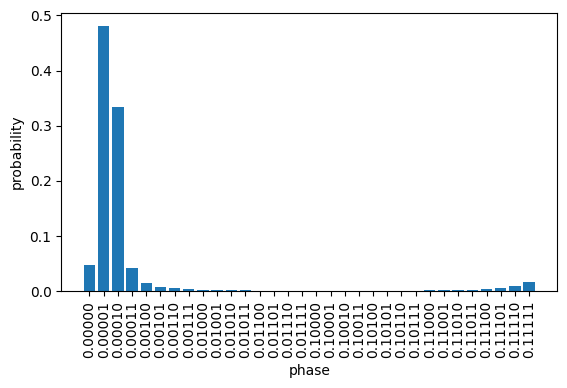

In [30]:


bit_strings = [f"0.{x:0{len(estimation_wires)}b}" for x in range(len(results))]

plt.bar(bit_strings, results)
plt.xlabel("phase")
plt.ylabel("probability")
plt.xticks(rotation="vertical")
plt.subplots_adjust(bottom=0.3)

plt.show()

In [31]:
state_and_p1 = []
for i in range(0,len(bit_strings)):
    dict_1 = {'state': '','probability':''}
    dict_1['state'] = bit_strings[i]
    dict_1['probability'] = results[i]
    state_and_p1.append(dict_1)

In [32]:
state_and_p1 

[{'state': '0.00000', 'probability': np.float64(0.04724038093623842)},
 {'state': '0.00001', 'probability': np.float64(0.48078137172403634)},
 {'state': '0.00010', 'probability': np.float64(0.33397349753253197)},
 {'state': '0.00011', 'probability': np.float64(0.04188288579274956)},
 {'state': '0.00100', 'probability': np.float64(0.015643815811164655)},
 {'state': '0.00101', 'probability': np.float64(0.008223952299749553)},
 {'state': '0.00110', 'probability': np.float64(0.00513666619679537)},
 {'state': '0.00111', 'probability': np.float64(0.003566807275664778)},
 {'state': '0.01000', 'probability': np.float64(0.0026641432453495587)},
 {'state': '0.01001', 'probability': np.float64(0.002100815919325811)},
 {'state': '0.01010', 'probability': np.float64(0.0017287702509156296)},
 {'state': '0.01011', 'probability': np.float64(0.0014733193788293466)},
 {'state': '0.01100', 'probability': np.float64(0.0012936073468526516)},
 {'state': '0.01101', 'probability': np.float64(0.001165908608281

where you just have one dominant peak you can just use this formula to obtain the answer:

$$\phi = \frac{\text{bin index}}{N} = \frac{\text{bin index}}{2^m}$$

In [33]:
N = 2**(len(estimation_wires))

state_and_p1_in_order = sorted(state_and_p1 , key=lambda x: x['probability'], reverse=True)
bin_index = ''

for i in range(len(state_and_p1)):
    if state_and_p1[i]['state'] == state_and_p1_in_order[0]['state']:
        bin_index = i
        break

phi_1 = bin_index/N

print(f'actual value is {np.pi/11} and estimated value from qpe is {2*np.pi*phi_1}')


actual value is 0.28559933214452665 and estimated value from qpe is 0.19634954084936207


if the output of the code is 2 peaks with very similar probability, a analytical solution such as the one below is required.

Now looking at the output of the circuit and from the visual graph it can be seen that we have more than one output. To find the exact solution, we use the following expression from Nielsen and Chuang:

$\alpha_l = \frac{1}{2^m} \left( \frac{1 - e^{2\pi i (2^m \delta - l)}}{1 - e^{2\pi i (\delta - l/2^m)}} \right)$

where $\alpha$ is the probability coefficient for each peak.

$\alpha^2 = p$ is the probability for each peak.


$m$: The number of estimation qubits.

$2^m = N$: The total number of states — in my case it's 32.

$\delta$: The true fractional offset. This is the exact distance between the true continuous phase and the closest representable integer state.

$l$: This tells us the distance between the two peaks. We always consider the two largest peaks when possible — in my case I have two peaks. I take $l = 0$ for the highest peak, which we treat as the central peak.

The second highest peak can vary in distance; if it was 5 bins away, $l = \pm 1, \pm 2, \ldots$. If the second peak is to the left of the highest peak it is given a negative sign; if it is to the right it is given a positive sign.

For our case the second highest peak has $l = 1$.

As for $\delta$, it is the fractional offset — the difference between the actual phase value and the closest integer bin, so it is a constant that varies with each different phase estimation.

$\delta = \phi - b/N$

$\delta_1 = \frac{1}{N} - \delta$

The method I leverage here is first squaring and reducing the general expression to obtain the probability, then leveraging a method known as peak interpolation where I take a ratio of $p_1/p_0$ to obtain a solution for $\delta$.

In [34]:
#Working out p1/p0 ratio where p0 > p1
ratio = (state_and_p1_in_order[1]['probability']/state_and_p1_in_order[0]['probability'])**0.5


In [35]:

delta = ratio/(N*(ratio+1)) 

b = 1
phi = delta + (b/N)
phi


np.float64(0.04545567711201246)

In [36]:
np.pi/11

0.28559933214452665

where $2\pi\phi = \pi/11$

In [37]:
print(f'actual value is {np.pi/11} and estimated value from qpe is {2*np.pi*phi}')

actual value is 0.28559933214452665 and estimated value from qpe is 0.2856064425580961
